In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

dftrain_raw = pd.read_csv("data/titanic/train.csv")
dftest_raw = pd.read_csv("data/titanic/test.csv")

dftrain_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,493,0,1,"Molson, Mr. Harry Markland",male,55.0,0,0,113787,30.5000,C30,S
1,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
2,388,1,2,"Buss, Miss. Kate",female,36.0,0,0,27849,13.0000,NaN,S
3,192,0,2,"Carbines, Mr. William",male,19.0,0,0,28424,13.0000,NaN,S
4,687,0,3,"Panula, Mr. Jaako Arnold",male,14.0,4,1,3101295,39.6875,NaN,S


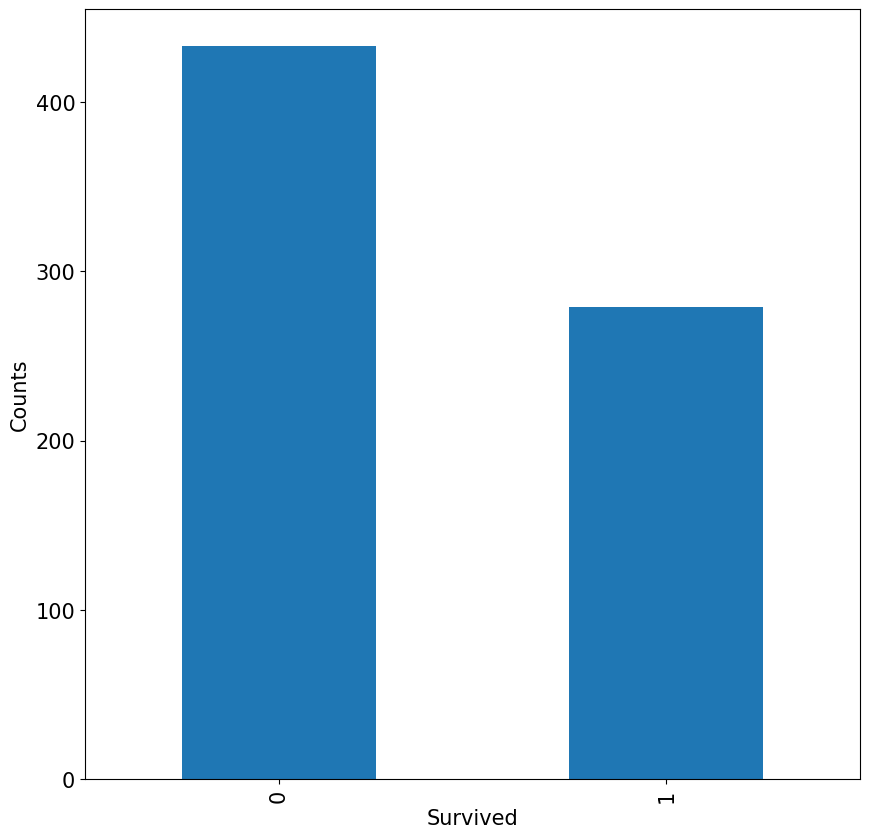

In [2]:
ax = dftrain_raw["Survived"].value_counts().plot(kind="bar", figsize=(10, 10), fontsize=15)
ax.set_ylabel("Counts", fontsize=15)
ax.set_xlabel("Survived", fontsize=15)
plt.show()

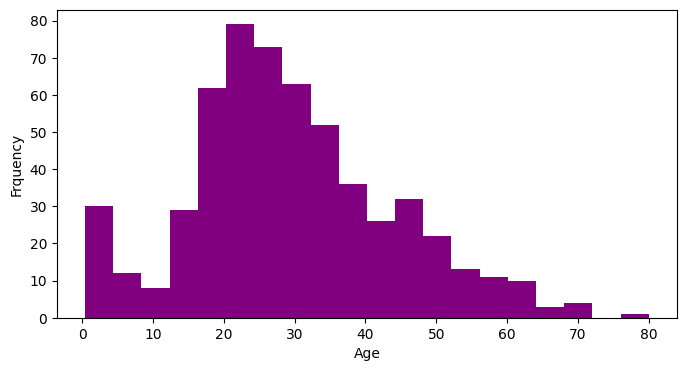

In [3]:
ax = dftrain_raw["Age"].plot(kind="hist", bins=20, color="purple", figsize=(8, 4), fontsize=10)
ax.set_ylabel("Frquency", fontsize=10)
ax.set_xlabel("Age", fontsize=10)
plt.show()

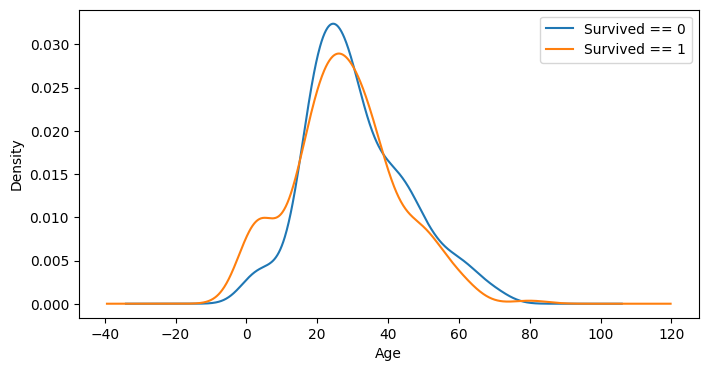

In [4]:
ax = dftrain_raw.query("Survived == 0")["Age"].plot(kind="density", figsize=(8, 4), fontsize=10)
dftrain_raw.query("Survived == 1")["Age"].plot(kind="density", figsize=(8, 4), fontsize=10)
ax.legend(["Survived == 0", "Survived == 1"])
ax.set_ylabel("Density", fontsize=10)
ax.set_xlabel("Age", fontsize=10)
plt.show()

In [14]:
def preprocessing(dfdata):
    dfresult = pd.DataFrame()
    # Pclass
    dfPclass = pd.get_dummies(dfdata["Pclass"])
    dfPclass.columns = ["PClass_" + str(x) for x in dfPclass.columns]
    dfresult = pd.concat([dfresult, dfPclass], axis=1)
    #Sex
    dfSex = pd.get_dummies(dfdata["Sex"])
    dfresult = pd.concat([dfresult, dfSex], axis=1)
    #Age
    dfresult["Age"] = dfdata["Age"].fillna(0)
    dfresult["Age_null"] = pd.isna(dfdata["Age"]).astype("int32")
    #SibSp, Parch, Fare
    dfresult["SibSp"] = dfdata["SibSp"]
    dfresult["Parch"] = dfdata["Parch"]
    dfresult["Fare"] = dfdata["Fare"]
    #Cabin
    dfresult["Cabin_null"] = pd.isna(dfdata["Cabin"]).astype("int32")
    # Embarked
    dfEmbarked = pd.get_dummies(dfdata["Embarked"], dummy_na=True)
    dfEmbarked.columns = ["Embarked_" + str(x) for x in dfEmbarked.columns]
    dfresult = pd.concat([dfresult, dfEmbarked], axis=1)
    return dfresult


x_train = preprocessing(dftrain_raw)
y_train = dftrain_raw["Survived"]

x_test = preprocessing(dftest_raw)
y_test = dftest_raw["Survived"]

print("x_train.shape", x_train.shape)
print("x_test.shape", x_test.shape)

x_train.shape (712, 15)
x_test.shape (179, 15)


In [15]:
tf.keras.backend.clear_session()

model = models.Sequential()
model.add(layers.Input(shape=(15, )))
model.add(layers.Dense(20, activation="relu"))
model.add(layers.Dense(10, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541 (2.11 KB)

 Trainable params: 541 (2.11 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["AUC"])

history = model.fit(x_train, y_train, batch_size=64, epochs=30, validation_split=0.2)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - AUC: 0.6877 - loss: 1.8382 - val_AUC: 0.6360 - val_loss: 1.6186
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.6878 - loss: 1.2587 - val_AUC: 0.6478 - val_loss: 1.1885
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.6966 - loss: 0.9845 - val_AUC: 0.6569 - val_loss: 0.8752
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.6957 - loss: 0.7752 - val_AUC: 0.6873 - val_loss: 0.6668
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.7073 - loss: 0.6277 - val_AUC: 0.7150 - val_loss: 0.6077
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.7397 - loss: 0.5919 - val_AUC: 0.7322 - val_loss: 0.5785
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.7545 - loss: 0.5877 - val_AUC: 0.7322 - val_loss: 0.5801
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.7579 - loss: 0.5743 - val_AUC: 0.7309 - val_loss: 0.5893
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.7701 - loss: 0.5670 - val_AUC:

In [17]:
def plot_metric(history, metric):
    train_metrics = history.history[metric]
    val_metrics = history.history["val_" + metric]
    epochs = range(1, len(train_metrics) + 1)
    plt.plot(epochs, train_metrics, "bo--")
    plt.plot(epochs, val_metrics, "ro--")
    plt.title("Training and validation" + metric)
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend(["train", "val"], loc="best")
    plt.show()

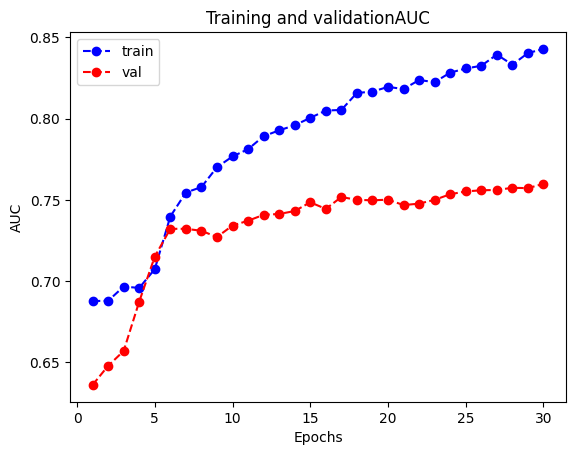

In [19]:
plot_metric(history, "AUC")

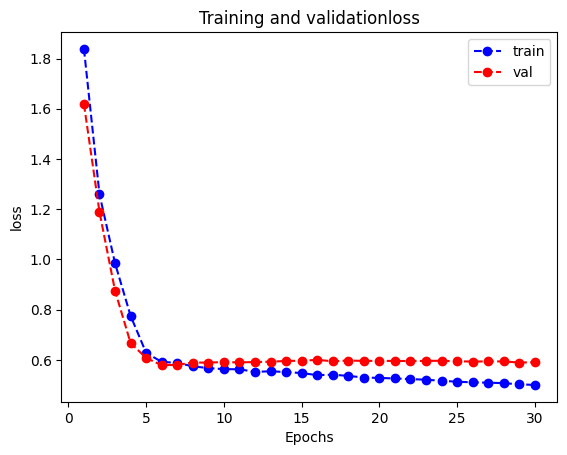

In [20]:
plot_metric(history, "loss")